In [ ]:
# -*- coding: utf-8 -*-
"""Cifar-10_from_scratch_MLP.ipynb

Original file is located at
    https://colab.research.google.com/drive/1Zy2JBb5zIW7LrwAK7r4xBQy7ENDx3L7h
"""

import numpy as np
import torch, torchvision, torchvision.transforms as T
from matplotlib import pyplot as plt
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')  # αν θέλεις να μένουν όλα μόνιμα
BASE_DIR = "/content/drive/MyDrive/nn_experiments"  # άλλαξέ το αν θέλεις

import os, json, csv, time, hashlib, textwrap
from datetime import datetime

def timestamp_id():
    return datetime.now().strftime("%Y%m%d-%H%M%S")

def ensure_dir(p):
    os.makedirs(p, exist_ok=True)

def code_fingerprint(cell_code: str):
    # Βάζεις εδώ προαιρετικά ολόκληρο το cell με το μοντέλο σου
    return hashlib.md5(cell_code.encode('utf-8')).hexdigest()[:10]

class Experiment:
    def __init__(self, base_dir, project="cifar10_mlp", run_name=None, config=None, code_sig=None):
        self.base = os.path.join(base_dir, project)
        ensure_dir(self.base)
        self.run_id = run_name or timestamp_id()
        self.dir = os.path.join(self.base, self.run_id)
        ensure_dir(self.dir)
        self.ckpt_dir = os.path.join(self.dir, "checkpoints")
        ensure_dir(self.ckpt_dir)
        self.fig_dir = os.path.join(self.dir, "figs")
        ensure_dir(self.fig_dir)
        self.misc_dir = os.path.join(self.dir, "misc")
        ensure_dir(self.misc_dir)

        self.config = config or {}
        self.config["run_id"] = self.run_id
        self.config["start_time"] = datetime.now().isoformat()
        self.config["code_signature"] = code_sig

        with open(os.path.join(self.dir, "config.json"), "w") as f:
            json.dump(self.config, f, indent=2, ensure_ascii=False)

        self.metrics_csv = os.path.join(self.dir, "metrics.csv")
        with open(self.metrics_csv, "w", newline="") as f:
            w = csv.writer(f)
            w.writerow(["epoch","train_loss","train_acc","val_loss","val_acc","lr","notes"])

    def log_epoch(self, epoch, train_loss, train_acc, val_loss, val_acc, lr, notes=""):
        with open(self.metrics_csv, "a", newline="") as f:
            csv.writer(f).writerow([epoch, float(train_loss), float(train_acc), float(val_loss), float(val_acc), float(lr), notes])

    def save_checkpoint(self, epoch, W1, b1, W2, b2, W3, b3):
        path = os.path.join(self.ckpt_dir, f"epoch_{epoch:04d}.npz")
        np.savez(path, W1=W1, b1=b1, W2=W2, b2=b2, W3=W3, b3=b3)
        return path


    def save_array(self, name, arr):
        np.save(os.path.join(self.misc_dir, f"{name}.npy"), arr)

    def plot_curves(self):
        data = np.genfromtxt(self.metrics_csv, delimiter=',', names=True)
        # Loss
        plt.figure()
        plt.plot(data["epoch"], data["train_loss"], label="train_loss")
        plt.plot(data["epoch"], data["val_loss"], label="val_loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss curves"); plt.legend()
        plt.savefig(os.path.join(self.fig_dir, "loss.png"), dpi=150); plt.close()
        # Accuracy
        plt.figure()
        plt.plot(data["epoch"], data["train_acc"], label="train_acc")
        plt.plot(data["epoch"], data["val_acc"], label="val_acc")
        plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy curves"); plt.legend()
        plt.savefig(os.path.join(self.fig_dir, "acc.png"), dpi=150); plt.close()

def confusion_matrix(y_true, y_pred, num_classes=10):
    cm = np.zeros((num_classes, num_classes), dtype=np.int32)
    for t,p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def save_confusion_matrix_png(cm, class_names, out_path):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation='nearest')
    plt.title("Confusion Matrix"); plt.colorbar()
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right"); plt.yticks(ticks, class_names)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150); plt.close()

def save_misclassified_grid(X_img_normed, mean, std, y_true, y_pred, max_samples=25, out_path="misclassified.png"):
    wrong_idx = np.where(y_true != y_pred)[0]
    if wrong_idx.size == 0:
        return
    sel = wrong_idx[:max_samples]
    C,H,W = 3,32,32
    imgs = X_img_normed[sel].reshape(-1, C, H, W).copy()

    cols = 5
    rows = int(np.ceil(len(sel)/cols))
    plt.figure(figsize=(cols*2, rows*2))
    for i,idx in enumerate(sel):
        plt.subplot(rows, cols, i+1)
        plt.imshow(np.transpose(imgs[i], (1,2,0)))
        plt.axis('off')
        plt.title(f"T:{y_true[idx]} P:{y_pred[idx]}", fontsize=8)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150); plt.close()

# CIFAR-10: 3×32×32, τιμές [0,1]
to_tensor = T.ToTensor()

train_set = torchvision.datasets.CIFAR10(
    root="/content/data", train=True, download=True, transform=to_tensor
)
test_set  = torchvision.datasets.CIFAR10(
    root="/content/data", train=False, download=True, transform=to_tensor
)

def ds_to_numpy(ds):
    X = np.stack([img.numpy() for (img, _) in ds]).astype(np.float32)      # (N, 3, 32, 32)
    y = np.array([lbl for (_, lbl) in ds], dtype=np.int64)                 # (N,)
    X = X.reshape(X.shape[0], -1)                                          # (N, 3072)
    return X, y

Xtr, ytr = ds_to_numpy(train_set)    # (50000, 3072). Τιμές στο [0, 1]
Xte, yte = ds_to_numpy(test_set)     # (10000, 3072). Τιμές στο [0, 1]

#Z-score Norm
# def compute_cifar10_channel_stats(X, y, C=3, H=32, W=32):
#     N = y.shape[0]
#     X_img = X.reshape(N, C, H, W)             # (N,3,32,32)
#     mean = X_img.mean(axis=(0, 2, 3))         # (3,)
#     std  = X_img.std(axis=(0, 2, 3)) + 1e-7   # (3,) + μικρό εψιλον
#     return mean.astype(np.float32), std.astype(np.float32)
# def normalize_per_channel(X, mean, std, C=3, H=32, W=32):
#     N = X.shape[0]
#     X_img = X.reshape(N, C, H, W)             # (N,3,32,32)
#     X_img = (X_img - mean[None, :, None, None]) / (std[None, :, None, None])
#     return X_img.reshape(N, C*H*W).astype(np.float32) # (N,3072)
# chan_mean, chan_std = compute_cifar10_channel_stats(Xtr, ytr)
# Xtr = normalize_per_channel(Xtr, chan_mean, chan_std)
# Xte = normalize_per_channel(Xte, chan_mean, chan_std)


X_train = Xtr.T      # (3072, 50000)
Y_train = ytr        # (50000,)
X_dev   = Xte.T      # (3072, 10000)
Y_dev   = yte        # (10000,)


CONFIG = {
  "dataset": "CIFAR-10",
  "input_dim": 3072,
  "hidden1": 512,
  "hidden2": 256,
  "output": 10,
  "activation": "Leaky ReLU",
  "optimizer": "SGD + Momentum",
  "momentum": 0.9,
  "initialization": "He (Kaiming) normal",
  "batching": "mini batch",
  "batch_size": 32,
  "print_every": 1,
  "log_every": 1,
  "shuffle": True,
  "epochs": 150,
  "learning_rate": 0.003,
  "normalization": "Standard Normalization ([0, 1])",
  "early_stopping": True,
  "l2_lambda": 0.001,
  "dropout1_rate": 0.28,
  "dropout2_rate": 0.15,
  "seed": 42,
  "best_epoch": -1,
  "label_smoothing_epsilon": 0.05,
  "run_id": "20251120-154931",
  "start_time": "2025-11-20T15:49:31.088757",
  "code_signature": "6f024060db"
}
np.random.seed(CONFIG["seed"])

CODE_SIG = code_fingerprint("""
# Βάλε εδώ (προαιρετικά) το cell με το μοντέλο/forward/ backward
""")

EXP = Experiment(
    base_dir=BASE_DIR,
    project="cifar10_mlp",
    config=CONFIG,
    code_sig=CODE_SIG
)
print("Run dir:", EXP.dir)

def init_param(input_dim=None, hidden1=None, hidden2=None, output=None, dtype=np.float32):
    if input_dim is None: input_dim = CONFIG.get("input_dim", 3072)
    if hidden1  is None: hidden1  = CONFIG.get("hidden1", 256)
    if hidden2  is None: hidden2  = CONFIG.get("hidden2", 128)
    if output   is None: output   = CONFIG.get("output", 10)

    # Layer 1: input -> hidden1
    W1 = np.random.randn(hidden1, input_dim).astype(dtype) * np.sqrt(2.0 / input_dim)
    b1 = np.zeros((hidden1, 1), dtype=dtype)

    # Layer 2: hidden1 -> hidden2
    W2 = np.random.randn(hidden2, hidden1).astype(dtype) * np.sqrt(2.0 / hidden1)
    b2 = np.zeros((hidden2, 1), dtype=dtype)

    # Layer 3: hidden2 -> output
    W3 = np.random.randn(output, hidden2).astype(dtype) * np.sqrt(2.0 / hidden2)
    b3 = np.zeros((output, 1), dtype=dtype)

    return W1, b1, W2, b2, W3, b3

# # Normal Relu
# def ReLU(Z):
#     return np.maximum(Z, 0)

# def ReLU_deriv(Z):
#     return Z > 0

def ReLU(Z):
    # Leaky ReLU με slope 0.01
    return np.maximum(0.01 * Z, Z)

def ReLU_deriv(Z):
    # Παράγωγος Leaky ReLU
    dZ = np.ones_like(Z)
    dZ[Z < 0] = 0.01
    return dZ

def softmax(Z):
    Zs = Z - np.max(Z, axis=0, keepdims=True)      # stability
    expZ = np.exp(Zs)
    return expZ / np.sum(expZ, axis=0, keepdims=True)

def one_hot(Y, num_classes=CONFIG["output"]):
    oh = np.zeros((num_classes, Y.size), dtype=np.float32)
    oh[Y, np.arange(Y.size)] = 1.0

    # 💥 LABEL SMOOTHING LOGIC
    epsilon = CONFIG.get("label_smoothing_epsilon", 0.0)
    if epsilon > 0.0:
        # Τιμή για τις λάθος κλάσεις
        low_val = epsilon / num_classes
        # Τιμή για τη σωστή κλάση
        high_val = 1.0 - epsilon + low_val

        # Εφαρμογή smoothing
        oh = oh * high_val + (1 - oh) * low_val

    return oh

def cross_entropy_loss(A2, Y):
    m = Y.size
    oh = one_hot(Y, num_classes=CONFIG["output"])
    return -np.sum(np.log(A2 + 1e-12) * oh) / m

def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    # print(predictions,Y)
    return np.sum(predictions == Y) / Y.size

def forward_prop(W1, b1, W2, b2, W3, b3, X,
                 dropout_rate1=0.0, dropout_rate2=0.0,
                 training=True):
    # Layer 1
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)

    mask1 = None
    if training and dropout_rate1 > 0.0:
        keep_prob1 = 1.0 - dropout_rate1
        mask1 = (np.random.rand(*A1.shape) < keep_prob1).astype(A1.dtype)
        A1 = (A1 * mask1) / keep_prob1     # inverted dropout

    # Layer 2
    Z2 = W2.dot(A1) + b2
    A2 = ReLU(Z2)

    mask2 = None
    if training and dropout_rate2 > 0.0:
        keep_prob2 = 1.0 - dropout_rate2
        mask2 = (np.random.rand(*A2.shape) < keep_prob2).astype(A2.dtype)
        A2 = (A2 * mask2) / keep_prob2     # inverted dropout

    # Output layer
    Z3 = W3.dot(A2) + b3
    A3 = softmax(Z3)

    # Επιστρέφουμε και τις 2 μάσκες
    return Z1, A1, Z2, A2, Z3, A3, mask1, mask2

def backward_prop(Z1, A1, Z2, A2, Z3, A3,
                  W1, W2, W3, X, Y,
                  mask1=None, mask2=None,
                  dropout_rate1=0.0, dropout_rate2=0.0):
    m = Y.size
    one_hot_Y = one_hot(Y)

    # Output layer
    dZ3 = A3 - one_hot_Y                            # (C, N)
    dW3 = (1.0 / m) * dZ3.dot(A2.T)                 # (C, hidden2)
    db3 = (1.0 / m) * np.sum(dZ3, axis=1, keepdims=True)  # (C,1)

    # Hidden layer 2
    dA2 = W3.T.dot(dZ3)                             # (hidden2, N)
    dZ2 = dA2 * ReLU_deriv(Z2)                      # (hidden2, N)

    # Dropout στο 2ο hidden
    if (mask2 is not None) and (dropout_rate2 > 0.0):
        keep_prob2 = 1.0 - dropout_rate2
        dZ2 = (dZ2 * mask2) / keep_prob2

    dW2 = (1.0 / m) * dZ2.dot(A1.T)                 # (hidden2, hidden1)
    db2 = (1.0 / m) * np.sum(dZ2, axis=1, keepdims=True)

    # Hidden layer 1
    dA1 = W2.T.dot(dZ2)                             # (hidden1, N)
    dZ1 = dA1 * ReLU_deriv(Z1)                      # (hidden1, N)

    # Dropout στο 1ο hidden
    if (mask1 is not None) and (dropout_rate1 > 0.0):
        keep_prob1 = 1.0 - dropout_rate1
        dZ1 = (dZ1 * mask1) / keep_prob1

    dW1 = (1.0 / m) * dZ1.dot(X.T)                  # (hidden1, input_dim)
    db1 = (1.0 / m) * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2, dW3, db3

def evaluate(W1, b1, W2, b2, W3, b3, X, Y, l2=0.0):
    Z1, A1, Z2, A2, Z3, A3, _, _ = forward_prop(
        W1, b1, W2, b2, W3, b3,
        X,
        dropout_rate1=0.0, dropout_rate2=0.0,
        training=False
    )

    preds = get_predictions(A3)
    acc = get_accuracy(preds, Y)

    ce_loss = cross_entropy_loss(A3, Y)

    # L2 Loss Term
    m = Y.size # Αυτό είναι το N
    if l2 > 0.0:
        l2_loss = (0.5 * l2 / m) * (np.sum(W1**2) + np.sum(W2**2) + np.sum(W3**2))
    else:
        l2_loss = 0.0

    loss = ce_loss + l2_loss
    return loss, acc, preds


def gradient_descent_logged(Xtr, Ytr, Xval, Yval,
                            alpha, epochs, print_every, log_every,
                            batch_size, shuffle=True):
    # init params
    W1, b1, W2, b2, W3, b3 = init_param(
        CONFIG["input_dim"],
        CONFIG["hidden1"],
        CONFIG["hidden2"],
        CONFIG["output"]
    )
    N = Ytr.size

    # --- Learning rate schedule setup ---
    initial_lr = alpha        # αρχικό lr από το CONFIG
    lr = initial_lr           # τρέχον lr

    # --- Momentum setup ---
    mu = CONFIG.get("momentum", 0.0)
    use_momentum = (mu > 0.0)

    vW1 = np.zeros_like(W1)
    vb1 = np.zeros_like(b1)
    vW2 = np.zeros_like(W2)
    vb2 = np.zeros_like(b2)
    vW3 = np.zeros_like(W3)
    vb3 = np.zeros_like(b3)

    # --- Early stopping setup ---
    patience = 10
    best_val_loss = float("inf")
    best_epoch = -1
    epochs_no_improve = 0
    best_params = None

    # --- Dropout & L2 ---
    dropout_rate1 = CONFIG.get("dropout1_rate", CONFIG.get("dropout_rate", 0.0))
    dropout_rate2 = CONFIG.get("dropout2_rate", CONFIG.get("dropout_rate", 0.0))
    l2 = CONFIG.get("l2_lambda", 0.0)

    for ep in range(epochs):
        # --- LR schedule: απλό step decay ---
        if ep == 50:    # 50 epochs με 0.01
            lr = initial_lr * 0.5 # Νέο LR: 0.005
        elif ep == 100: # 50 epochs με 0.005
            lr = initial_lr * 0.25 # Νέο LR: 0.0025

        # --- shuffle indices ---
        perm = np.random.permutation(N) if shuffle else np.arange(N)

        # --- mini-batch loop ---
        for s in range(0, N, batch_size):
            idx = perm[s:s+batch_size]
            Xb = Xtr[:, idx]
            Yb = Ytr[idx]

            # forward
            Z1, A1, Z2, A2, Z3, A3, mask1, mask2 = forward_prop(
                W1, b1, W2, b2, W3, b3,
                Xb,
                dropout_rate1=dropout_rate1,
                dropout_rate2=dropout_rate2,
                training=True
            )

            # backward
            dW1, db1, dW2, db2, dW3, db3 = backward_prop(
                Z1, A1, Z2, A2, Z3, A3,
                W1, W2, W3, Xb, Yb,
                mask1=mask1, mask2=mask2,
                dropout_rate1=dropout_rate1,
                dropout_rate2=dropout_rate2
            )

            # Update με ή χωρίς momentum (ΕΝΣΩΜΑΤΩΜΕΝΟ WEIGHT DECAY)
            if use_momentum:
                # vW = mu * vW - lr * (dW_CE + l2 * W)

                vW1 = mu * vW1 - lr * (dW1 + l2 * W1)
                vb1 = mu * vb1 - lr * db1

                vW2 = mu * vW2 - lr * (dW2 + l2 * W2)
                vb2 = mu * vb2 - lr * db2

                vW3 = mu * vW3 - lr * (dW3 + l2 * W3)
                vb3 = mu * vb3 - lr * db3

                W1 += vW1
                b1 += vb1
                W2 += vW2
                b2 += vb2
                W3 += vW3
                b3 += vb3
            else:
                # Standard SGD + L2
                W1 = W1 - lr * (dW1 + l2 * W1)
                b1 = b1 - lr * db1
                W2 = W2 - lr * (dW2 + l2 * W2)
                b2 = b2 - lr * db2
                W3 = W3 - lr * (dW3 + l2 * W3)
                b3 = b3 - lr * db3


        # --- αξιολόγηση μετά από κάθε epoch ---
        if (ep % log_every) == 0:
            tr_loss, tr_acc, _ = evaluate(W1, b1, W2, b2, W3, b3,
                                          Xtr, Ytr, l2=0.0)
            va_loss, va_acc, _ = evaluate(W1, b1, W2, b2, W3, b3,
                                          Xval, Yval, l2=0.0)

            EXP.log_epoch(ep, tr_loss, tr_acc, va_loss, va_acc, lr)

            if ep == 0 or ((ep+1) % print_every == 0) or (ep == epochs-1):
                print(f"Epoch {ep+1:3d}/{epochs} | "
                      f"train_loss {tr_loss:.4f} acc {tr_acc:.4f} | "
                      f"test_loss {va_loss:.4f} acc {va_acc:.4f} | "
                      f"bs {batch_size} | lr {lr:.5f}")

            # --- early stopping check ---
            if va_loss < best_val_loss - 1e-4:
                best_val_loss = va_loss
                best_epoch = ep      # 0-based index
                epochs_no_improve = 0
                best_params = (
                    W1.copy(), b1.copy(),
                    W2.copy(), b2.copy(),
                    W3.copy(), b3.copy()
                )
                EXP.save_checkpoint(ep, W1, b1, W2, b2, W3, b3)
            else:
                epochs_no_improve += 1

            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {ep+1} (best epoch: {best_epoch+1})")
                break

    # γύρνα στα καλύτερα weights αν υπάρχουν
    if best_params is not None:
        W1, b1, W2, b2, W3, b3 = best_params

    # αποθήκευση τελικών weights
    np.savez(os.path.join(EXP.ckpt_dir, "final.npz"),
             W1=W1, b1=b1, W2=W2, b2=b2, W3=W3, b3=b3)

    # γράψε και το best_epoch στο config.json (0-based ή 1-based όπως προτιμάς)
    EXP.config["best_epoch"] = best_epoch      # αν θες 1-based, βάλε best_epoch + 1
    with open(os.path.join(EXP.dir, "config.json"), "w") as f:
        json.dump(EXP.config, f, indent=2, ensure_ascii=False)

    return W1, b1, W2, b2, W3, b3

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Run dir: /content/drive/MyDrive/nn_experiments/cifar10_mlp/20251122-221032


In [2]:
start_time = time.time()

W1, b1, W2, b2, W3, b3 = gradient_descent_logged(
    X_train, Y_train, X_dev, Y_dev,
    alpha=CONFIG["learning_rate"],
    epochs=CONFIG["epochs"],
    print_every=CONFIG["print_every"], log_every=CONFIG["log_every"],
    batch_size=CONFIG["batch_size"]
)


total_sec = time.time() - start_time  # συνολικά δευτερόλεπτα
total_min = total_sec / 60.0

print(f"Total training time: {total_sec:.1f} sec ({total_min:.2f} min)")
with open(os.path.join(EXP.dir, "train_time.txt"), "w") as f:
    f.write(f"Total training time: {total_sec:.1f} sec ({total_min:.2f} min)\n")


Epoch   1/150 | train_loss 1.8069 acc 0.3913 | test_loss 1.8090 acc 0.3900 | bs 32 | lr 0.00300
Epoch   2/150 | train_loss 1.7308 acc 0.4198 | test_loss 1.7311 acc 0.4166 | bs 32 | lr 0.00300
Epoch   3/150 | train_loss 1.6877 acc 0.4332 | test_loss 1.6942 acc 0.4282 | bs 32 | lr 0.00300
Epoch   4/150 | train_loss 1.6502 acc 0.4496 | test_loss 1.6585 acc 0.4472 | bs 32 | lr 0.00300
Epoch   5/150 | train_loss 1.6257 acc 0.4546 | test_loss 1.6409 acc 0.4475 | bs 32 | lr 0.00300
Epoch   6/150 | train_loss 1.5864 acc 0.4660 | test_loss 1.6077 acc 0.4563 | bs 32 | lr 0.00300
Epoch   7/150 | train_loss 1.5599 acc 0.4868 | test_loss 1.5850 acc 0.4723 | bs 32 | lr 0.00300
Epoch   8/150 | train_loss 1.5330 acc 0.4880 | test_loss 1.5638 acc 0.4744 | bs 32 | lr 0.00300
Epoch   9/150 | train_loss 1.5559 acc 0.4875 | test_loss 1.5836 acc 0.4775 | bs 32 | lr 0.00300
Epoch  10/150 | train_loss 1.5160 acc 0.5038 | test_loss 1.5558 acc 0.4868 | bs 32 | lr 0.00300
Epoch  11/150 | train_loss 1.5059 acc 0.

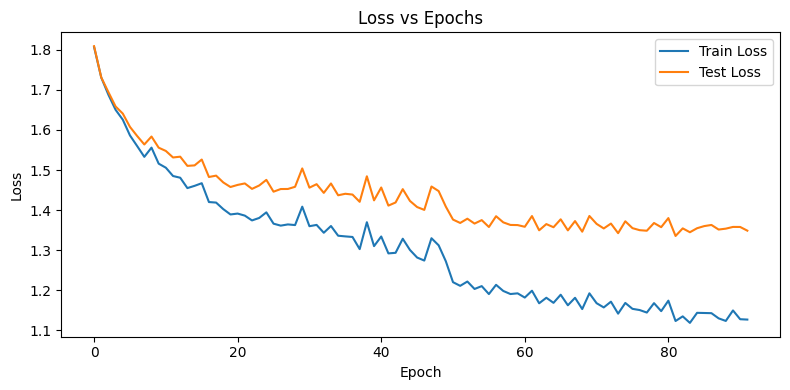

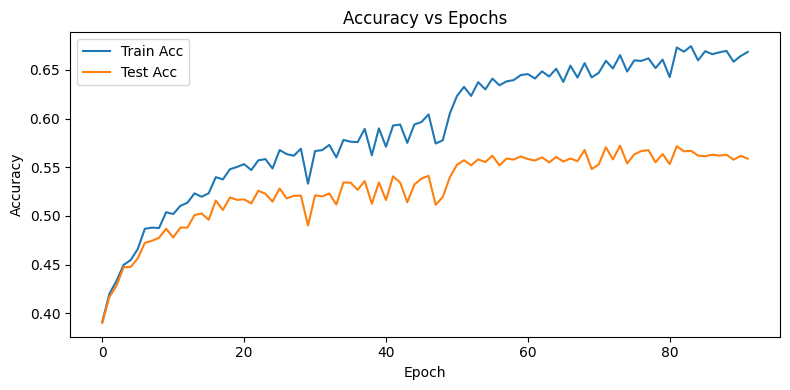

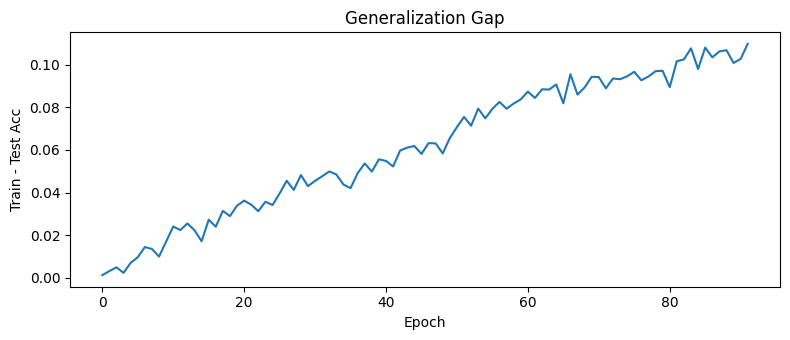

In [3]:
df = pd.read_csv(os.path.join(EXP.dir, "metrics.csv"))

# --- Loss ---
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(df["epoch"], df["train_loss"], label="Train Loss")
ax.plot(df["epoch"], df["val_loss"],  label="Test Loss")  # <-- άλλαξε label
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title("Loss vs Epochs"); ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(EXP.fig_dir, "loss_only.png"), dpi=150)
plt.show()
plt.close(fig)

# --- Accuracy ---
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(df["epoch"], df["train_acc"], label="Train Acc")
ax.plot(df["epoch"], df["val_acc"],   label="Test Acc")   # <-- άλλαξε label
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy"); ax.set_title("Accuracy vs Epochs"); ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(EXP.fig_dir, "acc_only.png"), dpi=150)
plt.show()
plt.close(fig)

# --- Generalization gap ---
gap = df["train_acc"] - df["val_acc"]
fig, ax = plt.subplots(figsize=(8,3.5))
ax.plot(df["epoch"], gap)
ax.set_xlabel("Epoch"); ax.set_ylabel("Train - Test Acc")  # ήδη σωστό
ax.set_title("Generalization Gap")
fig.tight_layout()
fig.savefig(os.path.join(EXP.fig_dir, "gen_gap.png"), dpi=150)
plt.show()
plt.close(fig)

Generating misclassified grid (10 samples)...


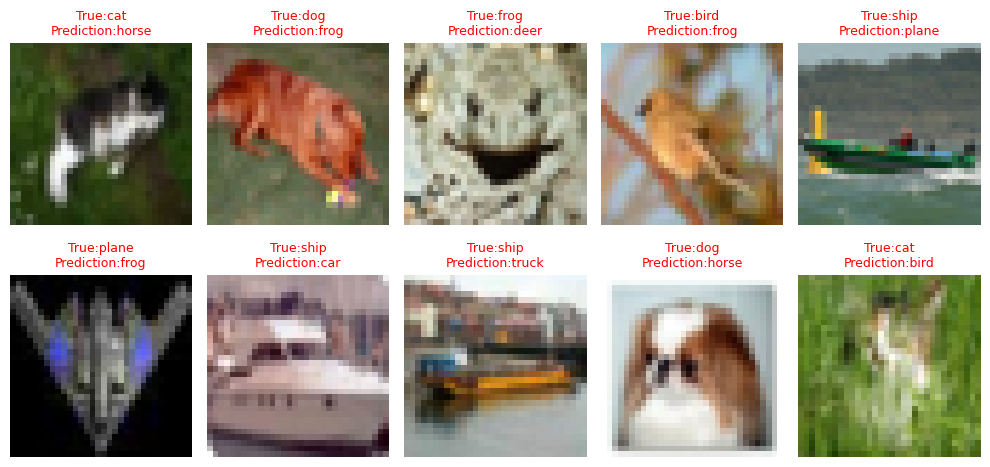

Generating correct classifications grid (10 samples)...


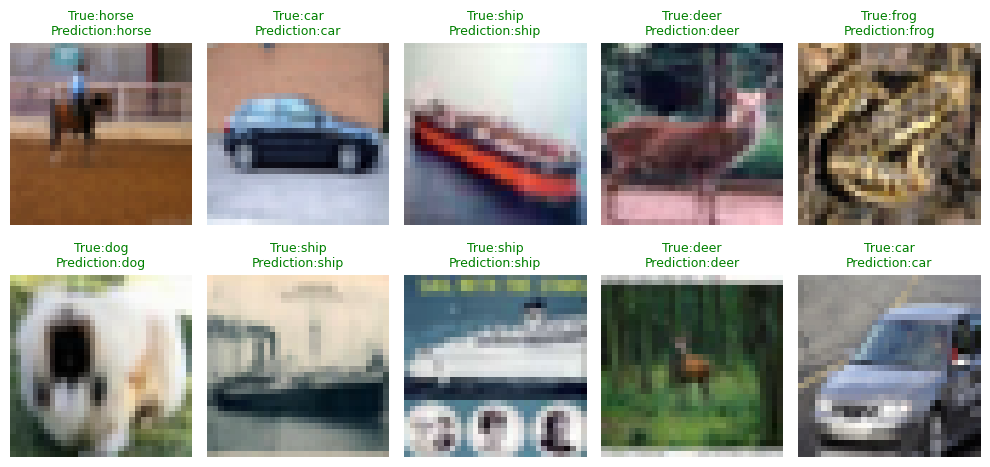

Generating per-class accuracy plot...
Class      | Accuracy
--------------------
plane      | 60.80%
car        | 67.50%
bird       | 40.10%
cat        | 39.70%
deer       | 52.40%
dog        | 40.90%
frog       | 61.60%
horse      | 70.90%
ship       | 71.40%
truck      | 66.30%


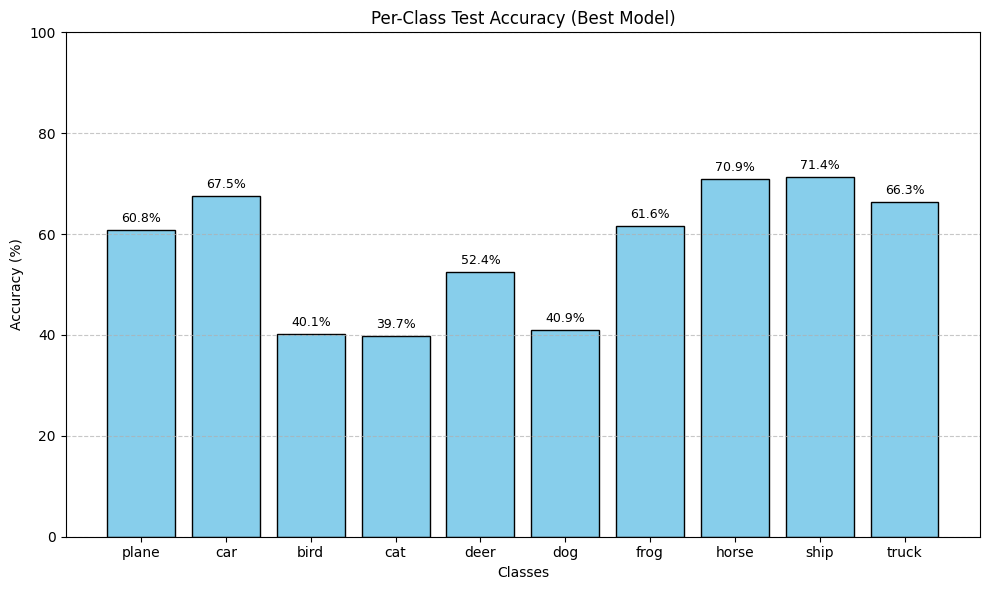

In [4]:
# --- Misclassified Images Visualization (10 samples) ---
def save_misclassified_grid(X, y_true, W1, b1, W2, b2, W3, b3, out_path, max_samples=10):
    # 1. Forward pass
    _, _, _, _, _, A3, _, _ = forward_prop(W1, b1, W2, b2, W3, b3, X, training=False)
    y_pred = get_predictions(A3)

    # 2. Find wrong indices
    wrong_idx = np.where(y_true != y_pred)[0]

    # 3. Select random samples (10)
    if len(wrong_idx) > max_samples:
        sel_idx = np.random.choice(wrong_idx, max_samples, replace=False)
    else:
        sel_idx = wrong_idx

    # 4. Plotting
    classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

    # Ρυθμίζουμε το grid για 10 εικόνες: 2 γραμμές x 5 στήλες
    cols = 5
    rows = int(np.ceil(len(sel_idx) / cols))

    plt.figure(figsize=(10, 5)) # Μικραίνουμε το ύψος της εικόνας

    for i, idx in enumerate(sel_idx):
        plt.subplot(rows, cols, i + 1)

        # Reshape & Un-normalize
        img = X[:, idx].reshape(3, 32, 32).transpose(1, 2, 0)
        img = (img - img.min()) / (img.max() - img.min())

        plt.imshow(img)
        plt.title(f"True:{classes[y_true[idx]]}\nPrediction:{classes[y_pred[idx]]}", fontsize=9, color='red')
        plt.axis('off')

    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    plt.close()

# --- Correct Images Visualization (10 samples) ---
def save_correct_grid(X, y_true, W1, b1, W2, b2, W3, b3, out_path, max_samples=10):
    # 1. Forward pass
    _, _, _, _, _, A3, _, _ = forward_prop(W1, b1, W2, b2, W3, b3, X, training=False)
    y_pred = get_predictions(A3)

    # 2. Find correct indices
    correct_idx = np.where(y_true == y_pred)[0]

    # 3. Select random samples (10)
    if len(correct_idx) > max_samples:
        sel_idx = np.random.choice(correct_idx, max_samples, replace=False)
    else:
        sel_idx = correct_idx

    # 4. Plotting
    classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

    # Ρυθμίζουμε το grid για 10 εικόνες: 2 γραμμές x 5 στήλες
    cols = 5
    rows = int(np.ceil(len(sel_idx) / cols))

    plt.figure(figsize=(10, 5)) # Μικραίνουμε το ύψος της εικόνας

    for i, idx in enumerate(sel_idx):
        plt.subplot(rows, cols, i + 1)

        # Reshape & Un-normalize
        img = X[:, idx].reshape(3, 32, 32).transpose(1, 2, 0)
        img = (img - img.min()) / (img.max() - img.min())

        plt.imshow(img)
        plt.title(f"True:{classes[y_true[idx]]}\nPrediction:{classes[y_pred[idx]]}", fontsize=9, color='green')
        plt.axis('off')

    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    plt.close()

# Εκτέλεση
print("Generating misclassified grid (10 samples)...")
save_misclassified_grid(X_dev, Y_dev, W1, b1, W2, b2, W3, b3,
                        os.path.join(EXP.fig_dir, "misclassified.png"))

print("Generating correct classifications grid (10 samples)...")
save_correct_grid(X_dev, Y_dev, W1, b1, W2, b2, W3, b3,
                  os.path.join(EXP.fig_dir, "correct_samples.png"))
def plot_per_class_accuracy(X, y_true, W1, b1, W2, b2, W3, b3, out_path):
    # 1. Get Predictions
    _, _, _, _, _, A3, _, _ = forward_prop(W1, b1, W2, b2, W3, b3, X, training=False)
    y_pred = get_predictions(A3)

    classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
    class_accs = []

    # 2. Calculate Accuracy per Class
    print(f"{'Class':<10} | Accuracy")
    print("-" * 20)
    for c in range(10):
        idx = (y_true == c)
        total = np.sum(idx)
        correct = np.sum(y_true[idx] == y_pred[idx])
        acc = correct / total if total > 0 else 0
        class_accs.append(acc * 100)
        print(f"{classes[c]:<10} | {acc*100:.2f}%")

    # 3. Plot Bar Chart
    plt.figure(figsize=(10, 6))
    bars = plt.bar(classes, class_accs, color='skyblue', edgecolor='black')
    plt.xlabel('Classes')
    plt.ylabel('Accuracy (%)')
    plt.title('Per-Class Test Accuracy (Best Model)')
    plt.ylim(0, 100)

    # Add numbers on top of bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.1f}%", ha='center', va='bottom', fontsize=9)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    plt.close()

print("Generating per-class accuracy plot...")
plot_per_class_accuracy(X_dev, Y_dev, W1, b1, W2, b2, W3, b3,
                        os.path.join(EXP.fig_dir, "per_class_acc.png"))